In [75]:
import numpy as np
import pandas as pd
import random
from matplotlib import pyplot as plt

In [76]:
dataset = pd.read_csv('dataset/train.csv')
test_dataset = pd.read_csv("dataset/test.csv")

In [77]:
dataset.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [78]:
data = np.array(dataset)
m,n = data.shape
np.random.shuffle(data)

data_dev = data[0:1000].T
Y_dev = data_dev[0]
X_dev = data_dev[1:n]

data_train = data[1000:m].T
Y_train = data_train[0]
X_train = data_train[1:n]
X_train = X_train / 255.0

In [79]:
test_data = np.array(test_dataset)
X_test = test_data.T  # Shape: (784, 28000)
X_test = X_test / 255.0  # Normalize

In [80]:
print(test_dataset.shape)
print(test_dataset.columns)

(28000, 784)
Index(['pixel0', 'pixel1', 'pixel2', 'pixel3', 'pixel4', 'pixel5', 'pixel6',
       'pixel7', 'pixel8', 'pixel9',
       ...
       'pixel774', 'pixel775', 'pixel776', 'pixel777', 'pixel778', 'pixel779',
       'pixel780', 'pixel781', 'pixel782', 'pixel783'],
      dtype='str', length=784)


In [81]:

#Todo - Research initilization techniques. Came across He initilization for the RELU activation function
# def init_params():
#     W1 = np.random.rand(10, 784) - 0.5
#     b1 = np.random.rand(10, 1) - 0.5
#     W2 = np.random.rand(10, 10) - 0.5
#     b2 = np.random.rand(10, 1) - 0.5
#     return W1, b1, W2, b2


# He initilization
def init_params():
    W1 = np.random.randn(10, 784) * np.sqrt(2/784)
    b1 = np.zeros((10,1))
    W2 = np.random.randn(10, 10) * np.sqrt(2/10)
    b2 = np.zeros((10,1))

    return W1, b1, W2, b2

def ReLu(Z):
   return np.maximum(0, Z)


def softmax(Z):
    Z = Z - np.max(Z, axis=0, keepdims=True)
    expZ = np.exp(Z)
    return expZ / np.sum(expZ, axis=0, keepdims=True)
    

def forward_prop(W1,b1,W2,b2, X):
    Z1 = W1 @ X + b1
    A1 = ReLu(Z1)
    Z2 = W2 @ A1 + b2
    A2 = softmax(Z2)
    return Z1, A1, Z2, A2

def one_hot(Y):
    one_hot_Y = np.zeros((Y.size, Y.max() + 1))
    one_hot_Y[np.arange(Y.size), Y] = 1
    one_hot_Y = one_hot_Y.T
    return one_hot_Y

def deriv_ReLu(Z):
    return Z > 0

def back_prop(Z1, A1, Z2, A2, W2, X, Y):

    m = Y.size
    one_hot_Y = one_hot(Y)

    dZ2 = A2 - one_hot_Y
    dW2 = 1/m * dZ2 @ A1.T
    db2 = 1/m * np.sum(dZ2, axis=1, keepdims=True)

    dZ1 = W2.T @ dZ2 * deriv_ReLu(Z1)
    dW1 = 1/m * dZ1 @ X.T
    db1 = 1/m * np.sum(dZ1, axis=1, keepdims=True)

    return dW1, db1, dW2, db2

def update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, alpha):
    W1 = W1 - alpha * dW1
    b1 = b1 - alpha * db1
    
    W2 = W2 - alpha * dW2
    b2 = b2 - alpha * db2
    return W1, b1, W2, b2
    


In [82]:
def get_predictions(A2):
    return np.argmax(A2, 0)

def get_accuracy(predictions, Y):
    print(predictions, Y)
    return np.sum(predictions == Y) / Y.size

In [83]:
def gradient_descent(X, Y, iterations, alpha):
    W1, b1, W2, b2 = init_params()
    for i in range(iterations):
        Z1, A1, Z2, A2 = forward_prop(W1, b1, W2, b2, X)
        dW1, db1, dW2, db2 = back_prop(Z1, A1, Z2, A2, W2, X, Y)
        W1, b1, W2, b2 = update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, alpha)
        if i % 10 == 0:
            print("Iteration:", i)
            print("Accuracy: ", get_accuracy(get_predictions(A2), Y))
            
    return W1, b1, W2, b2

In [84]:
W1, b1, W2, b2 = gradient_descent(X_train, Y_train, 500, 0.1)

Iteration: 0
[7 7 7 ... 7 7 7] [5 7 3 ... 7 7 6]
Accuracy:  0.13953658536585367
Iteration: 10
[0 7 9 ... 7 7 0] [5 7 3 ... 7 7 6]
Accuracy:  0.35434146341463413
Iteration: 20
[0 7 9 ... 7 7 6] [5 7 3 ... 7 7 6]
Accuracy:  0.5414634146341464
Iteration: 30
[6 7 9 ... 7 7 6] [5 7 3 ... 7 7 6]
Accuracy:  0.659829268292683
Iteration: 40
[6 7 8 ... 7 7 6] [5 7 3 ... 7 7 6]
Accuracy:  0.6916097560975609
Iteration: 50
[6 7 3 ... 7 7 6] [5 7 3 ... 7 7 6]
Accuracy:  0.7124390243902439
Iteration: 60
[5 7 3 ... 7 7 6] [5 7 3 ... 7 7 6]
Accuracy:  0.7380487804878049
Iteration: 70
[5 7 3 ... 7 7 6] [5 7 3 ... 7 7 6]
Accuracy:  0.765
Iteration: 80
[5 7 3 ... 7 7 6] [5 7 3 ... 7 7 6]
Accuracy:  0.7883658536585366
Iteration: 90
[5 7 3 ... 7 7 6] [5 7 3 ... 7 7 6]
Accuracy:  0.8050487804878049
Iteration: 100
[5 7 3 ... 7 7 6] [5 7 3 ... 7 7 6]
Accuracy:  0.8185365853658536
Iteration: 110
[5 7 3 ... 7 7 6] [5 7 3 ... 7 7 6]
Accuracy:  0.829
Iteration: 120
[5 7 3 ... 7 7 6] [5 7 3 ... 7 7 6]
Accuracy:  0.

In [85]:
def make_predictions(X, W1, b1, W2, b2):
    _, _, _, A2 = forward_prop(W1, b1, W2, b2, X)
    predictions = get_predictions(A2)
    return predictions

def test_prediction(index, W1, b1, W2, b2):
    current_image = X_train[:, index, None]
    prediction = make_predictions(X_train[:, index, None], W1, b1, W2, b2)
    label = Y_train[index]
    print("Prediction: ", prediction)
    print("Label: ", label)
    
    current_image = current_image.reshape((28, 28)) * 255
    plt.gray()
    plt.imshow(current_image, interpolation='nearest')
    plt.show()

Prediction:  [2]
Label:  5


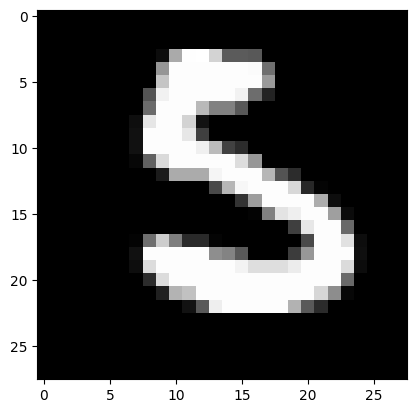

Prediction:  [8]
Label:  5


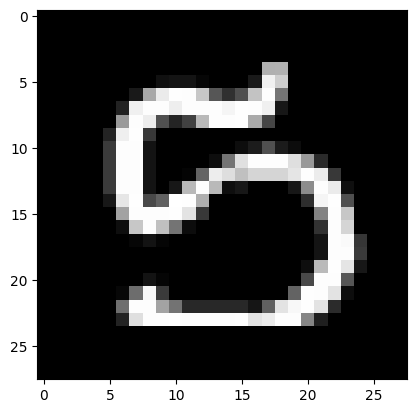

Prediction:  [4]
Label:  4


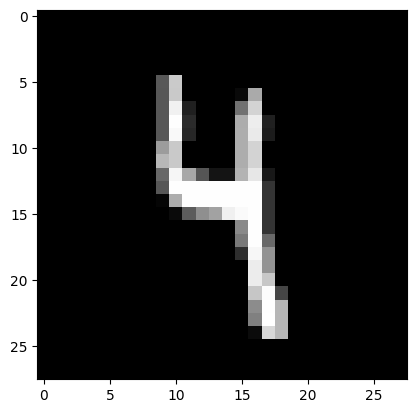

Prediction:  [7]
Label:  7


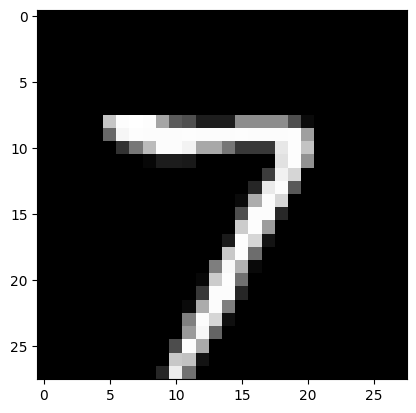

In [86]:
test_prediction(random.randint(1,784), W1, b1, W2, b2)
test_prediction(random.randint(1,784), W1, b1, W2, b2)
test_prediction(random.randint(1,784), W1, b1, W2, b2)
test_prediction(random.randint(1,784), W1, b1, W2, b2)

In [87]:
test_predictions = make_predictions(X_dev, W1, b1, W2, b2)
get_accuracy(test_predictions, Y_dev)

[6 2 9 1 5 3 0 5 5 2 4 1 0 0 7 2 7 3 5 5 6 8 1 8 0 5 0 4 3 7 5 5 4 4 3 2 5
 1 9 2 7 5 8 1 4 6 7 8 0 8 8 4 8 6 0 3 5 4 0 6 6 1 3 1 0 9 9 6 2 6 2 3 5 4
 8 5 4 3 9 1 4 0 0 1 0 6 6 8 8 3 7 1 6 9 3 6 5 3 8 8 0 3 1 4 7 9 0 0 8 4 5
 0 1 1 6 9 9 2 5 0 7 6 5 8 7 9 6 9 7 6 7 6 1 5 1 2 5 8 6 0 1 6 0 3 7 2 2 3
 7 6 0 1 8 1 2 8 1 3 7 7 4 3 4 1 7 3 0 9 6 6 9 2 5 3 8 0 6 6 5 7 9 7 2 4 8
 1 8 2 1 8 4 9 1 1 6 0 9 4 6 3 4 9 2 3 9 5 4 0 8 5 7 2 2 0 5 0 8 1 3 5 7 2
 0 0 0 0 2 3 8 3 7 9 5 4 8 1 9 6 2 7 7 3 5 2 3 7 2 4 8 9 6 3 9 0 9 2 2 0 1
 6 2 5 3 1 7 5 1 6 7 7 2 6 1 6 8 9 9 5 8 6 9 8 3 3 4 2 5 7 7 9 3 3 3 3 4 1
 9 1 5 8 7 7 5 9 3 1 7 8 7 2 9 1 4 3 4 6 9 0 9 2 1 7 1 4 0 6 6 9 6 1 8 6 3
 6 7 6 2 6 5 1 7 3 3 1 0 7 3 7 3 1 6 1 5 0 7 1 8 6 1 8 8 0 3 3 8 5 3 6 2 5
 0 8 3 9 2 9 2 3 6 8 5 9 6 9 7 5 3 3 8 1 0 9 5 0 5 5 5 6 6 1 8 8 6 4 1 8 8
 2 4 3 1 8 4 9 6 5 2 2 9 6 1 6 1 7 6 6 2 6 6 3 1 6 7 0 8 2 1 5 9 1 8 6 4 2
 8 6 2 7 6 0 2 6 0 8 4 2 6 5 7 9 2 5 0 7 2 9 2 0 6 5 6 1 4 2 0 9 4 5 9 8 4
 7 7 1 3 7 0 8 4 5 2 1 0 

np.float64(0.888)